# LOO Ablation — Publication-quality plots

Visualises results from `results/ablation_loo.csv` (generated by `ablation_loo.py`).

**Three figures:**
1. CF metrics — holdout (OOD) vs in-distribution, targets pooled
2. CF metrics — split by target (CRC / TVA)
3. Run-level metrics (ARI, NMI, marginal log-likelihood)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ── Nature-style rcParams ─────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":          7,
    "axes.labelsize":     7,
    "axes.titlesize":     8,
    "axes.linewidth":     0.8,
    "xtick.labelsize":    6,
    "ytick.labelsize":    6,
    "xtick.major.width":  0.8,
    "ytick.major.width":  0.8,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "legend.fontsize":    6,
    "legend.frameon":     False,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "pdf.fonttype":       42,   # editable fonts in PDF
    "ps.fonttype":        42,
})

In [2]:
# ── Load & preprocess ─────────────────────────────────────────────────────────
df = pd.read_csv("results/ablation_loo.csv")

# lpw=0 is rendered as a baseline line, not a bar group
LPW_ORDER       = ["0.01", "0.1", "1.0"]
LPW_TICK_LABELS = ["0.01", "0.1", "1"  ]

SLT_ORDER  = ["supcon", "domain_clf"]

SLT_COLORS  = {"supcon": "#4C72B0", "domain_clf": "#C44E52"}
SLT_HATCHES = {"supcon": "",        "domain_clf": "//"}    # B&W-friendly
SLT_LABELS  = {"supcon": "SupCon",  "domain_clf": "Domain clf"}

CF_METRICS  = ["pearson_r", "spearman_r", "precision", "mixing_index"]
RUN_METRICS = ["marginal_ll", "ari", "nmi"]

METRIC_LABELS = {
    "pearson_r":    "Pearson r",
    "spearman_r":   "Spearman r",
    "precision":    "Precision@50",
    "mixing_index": "Mixing index",
    "marginal_ll":  "Marginal log-likelihood",
    "ari":          "ARI",
    "nmi":          "NMI",
}

df["lpw_str"] = df["link_prediction_weight"].astype(str)

print(f"Rows: {len(df)}")
print(f"lpw_str values: {sorted(df['lpw_str'].unique())}")

Rows: 336
lpw_str values: ['0.0', '0.01', '0.1', '1.0']


In [3]:
# df = df[df['holdout_celltype'].isin(['Epithelial', 'T_cell'])] 

In [4]:
# ── Aggregation helpers ───────────────────────────────────────────────────────

def sem(x):
    """Standard error of mean."""
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0


def agg_cf(df, is_holdout_val, target=None):
    """Mean ± SEM of CF metrics across cell types / holdout conditions / targets."""
    sub = df[df["is_holdout"] == is_holdout_val]
    if target is not None:
        sub = sub[sub["target"] == target]
    g = sub.groupby(["lpw_str", "spatial_loss_type"])
    result = {}
    for metric in CF_METRICS:
        m = g[metric].agg(["mean", sem]).reset_index()
        m.columns = ["lpw_str", "spatial_loss_type", "mean", "sem"]
        result[metric] = m
    return result


def agg_run(df):
    """Mean ± SEM of run metrics across holdout cell types (one row per run)."""
    run_df = df.drop_duplicates(["holdout_celltype", "link_prediction_weight", "spatial_loss_type"])
    g = run_df.groupby(["lpw_str", "spatial_loss_type"])
    result = {}
    for metric in RUN_METRICS:
        m = g[metric].agg(["mean", sem]).reset_index()
        m.columns = ["lpw_str", "spatial_loss_type", "mean", "sem"]
        result[metric] = m
    return result


def baseline_val(agg_metric_df):
    """Return the lpw=0 supcon mean as the shared baseline scalar (spatial loss off)."""
    sub = agg_metric_df[
        (agg_metric_df["lpw_str"] == "0.0") &
        (agg_metric_df["spatial_loss_type"] == "supcon")
    ]
    return float(sub["mean"].iloc[0]) if len(sub) else None

In [5]:
# ── Core barplot helper ───────────────────────────────────────────────────────

def grouped_barplot(
    ax, metric_df, lpw_order, slt_order,
    slt_colors, slt_hatches, slt_labels,
    tick_labels=None,
    baseline=None,      # scalar: drawn as a horizontal dashed line (lpw=0 baseline)
    ylabel=None, title=None, show_legend=False, show_xlabel=True,
    ylim=None,
):
    """
    metric_df  : DataFrame with columns [lpw_str, spatial_loss_type, mean, sem]
    baseline   : float — if provided, draw a dashed gray reference line
    show_xlabel: set False to suppress the x-axis label (non-bottom panels)
    """
    if tick_labels is None:
        tick_labels = lpw_order

    n_slt  = len(slt_order)
    bar_w  = 0.38
    group_w = bar_w * n_slt + 0.12
    x      = np.arange(len(lpw_order)) * group_w
    offsets = np.linspace(-(n_slt - 1) / 2, (n_slt - 1) / 2, n_slt) * bar_w

    for i, slt in enumerate(slt_order):
        sub   = metric_df[metric_df["spatial_loss_type"] == slt].set_index("lpw_str")
        means = [sub.loc[lpw, "mean"] if lpw in sub.index else np.nan for lpw in lpw_order]
        sems  = [sub.loc[lpw, "sem"]  if lpw in sub.index else np.nan for lpw in lpw_order]
        ax.bar(
            x + offsets[i], means, bar_w * 0.92,
            yerr=sems, capsize=2.0,
            color=slt_colors[slt], hatch=slt_hatches[slt],
            edgecolor="white", linewidth=0.5,
            label=slt_labels[slt],
            error_kw=dict(linewidth=0.8, ecolor="0.25", capthick=0.8),
            zorder=3,
        )

    if baseline is not None:
        ax.axhline(
            baseline, linestyle="--", color="0.40", linewidth=0.9,
            label="No spatial loss (lpw=0)", zorder=4,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, fontsize=6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linewidth=0.4, color="0.85", zorder=0)
    ax.set_axisbelow(True)

    if show_xlabel: ax.set_xlabel("Link prediction weight", fontsize=7, labelpad=2)
    if ylabel:      ax.set_ylabel(ylabel, fontsize=7, labelpad=3)
    if title:       ax.set_title(title, fontsize=8, pad=3)
    if ylim:        ax.set_ylim(*ylim)
    # if show_legend: ax.legend(fontsize=6, frameon=False, handlelength=1.4)

## Figure 1 — CF metrics: LOO (OOD) vs in-distribution  *(targets pooled)*

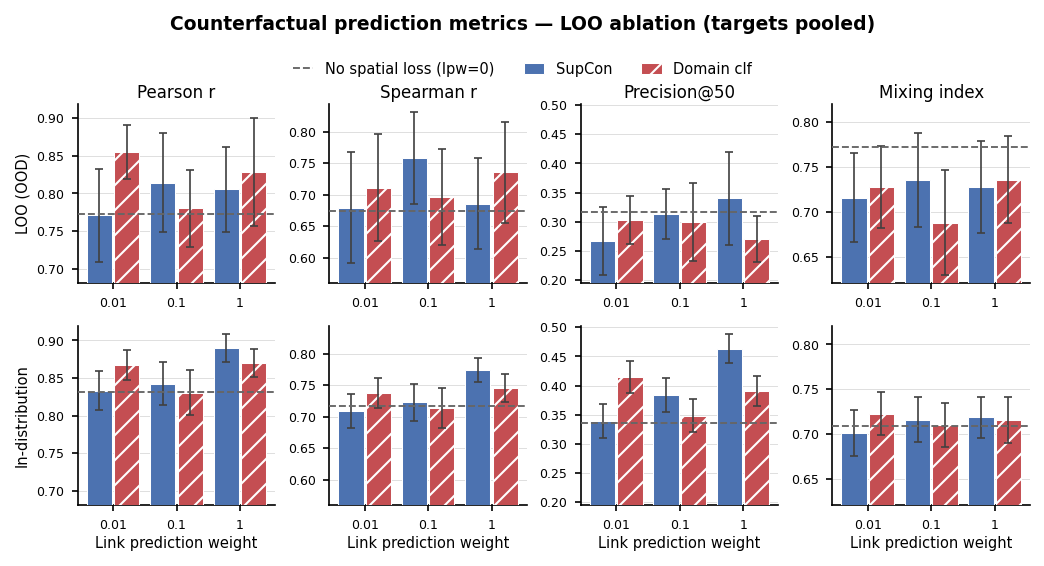

In [6]:
agg_holdout = agg_cf(df, is_holdout_val=True)
agg_inDist  = agg_cf(df, is_holdout_val=False)

def shared_ylims(agg_dict_list, metrics, pad=0.05):
    ylims = {}
    for m in metrics:
        vals = pd.concat([d[m] for d in agg_dict_list])
        lo = (vals["mean"] - vals["sem"]).min()
        hi = (vals["mean"] + vals["sem"]).max()
        rng = hi - lo
        ylims[m] = (max(0, lo - pad * rng), hi + pad * rng)
    return ylims

ylims1 = shared_ylims([agg_holdout, agg_inDist], CF_METRICS)

fig1, axes1 = plt.subplots(2, 4, figsize=(6.85, 3.2), constrained_layout=True)

row_labels = ["LOO (OOD)", "In-distribution"]
agg_rows   = [agg_holdout, agg_inDist]
is_bottom  = [False, True]

for row_i, (row_label, agg_dict, bottom) in enumerate(zip(row_labels, agg_rows, is_bottom)):
    for col_i, metric in enumerate(CF_METRICS):
        ax = axes1[row_i, col_i]
        grouped_barplot(
            ax, agg_dict[metric],
            lpw_order=LPW_ORDER, tick_labels=LPW_TICK_LABELS,
            slt_order=SLT_ORDER,
            slt_colors=SLT_COLORS, slt_hatches=SLT_HATCHES, slt_labels=SLT_LABELS,
            baseline=baseline_val(agg_dict[metric]),
            title=METRIC_LABELS[metric] if row_i == 0 else None,
            ylabel=row_label if col_i == 0 else None,
            show_xlabel=bottom,
            ylim=ylims1[metric],
        )

handles, labels = axes1[0, 0].get_legend_handles_labels()
fig1.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.06),
            ncols=len(handles), fontsize=7, frameon=False, handlelength=1.4)
fig1.suptitle("Counterfactual prediction metrics — LOO ablation (targets pooled)",
              fontsize=9, weight="bold", y=1.13)
plt.show()

## Figure 2 — CF metrics split by target (CRC vs TVA)

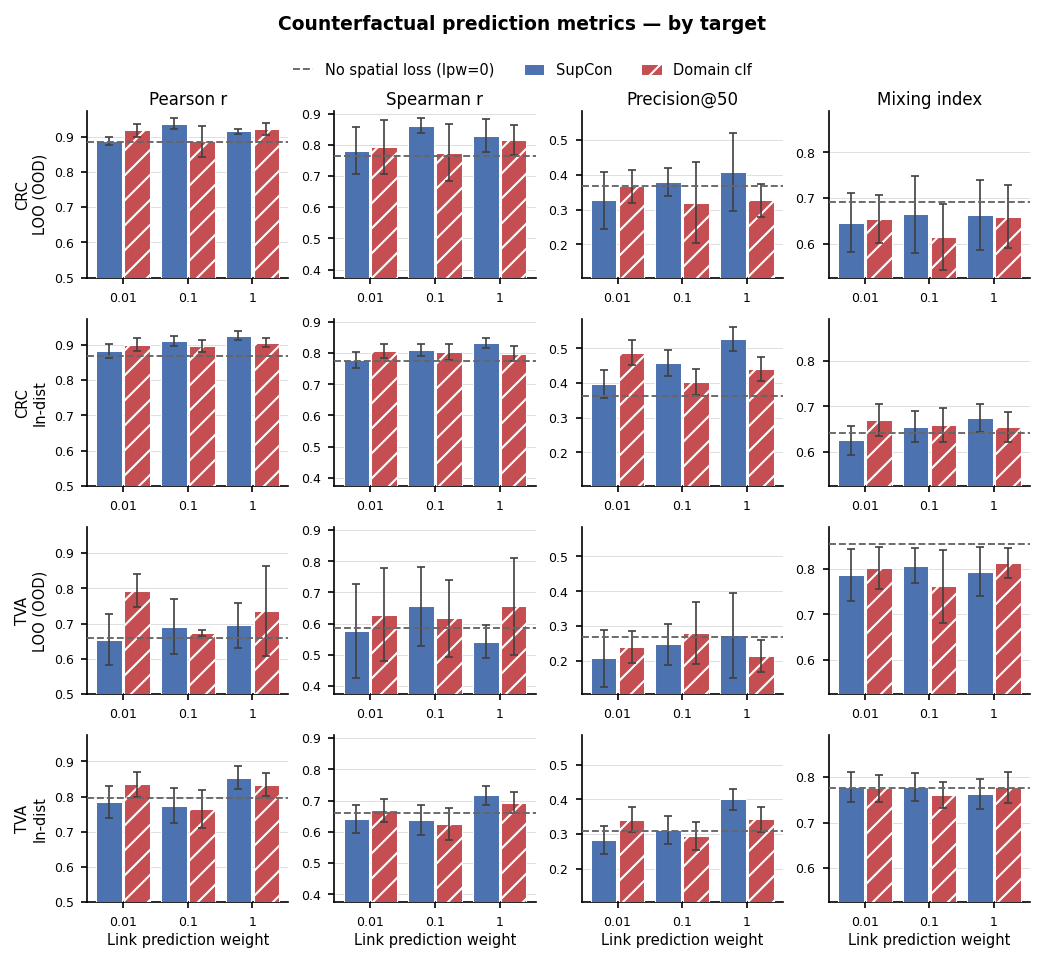

In [7]:
TARGETS = sorted(df["target"].unique())   # ['CRC', 'TVA']

agg_by_target = {
    tgt: {
        "holdout": agg_cf(df, is_holdout_val=True,  target=tgt),
        "inDist":  agg_cf(df, is_holdout_val=False, target=tgt),
    }
    for tgt in TARGETS
}

all_aggs = [agg_by_target[tgt][cond] for tgt in TARGETS for cond in ["holdout", "inDist"]]
ylims2 = shared_ylims(all_aggs, CF_METRICS)

fig2, axes2 = plt.subplots(4, 4, figsize=(6.85, 5.8), constrained_layout=True)

cond_keys   = ["holdout", "inDist"]
row_ylabels = ["CRC\nLOO (OOD)", "CRC\nIn-dist", "TVA\nLOO (OOD)", "TVA\nIn-dist"]

for t_i, tgt in enumerate(TARGETS):
    for c_i, cond in enumerate(cond_keys):
        row_i    = t_i * 2 + c_i
        agg_dict = agg_by_target[tgt][cond]
        is_top    = (row_i == 0)
        is_bottom = (row_i == len(TARGETS) * 2 - 1)

        for col_i, metric in enumerate(CF_METRICS):
            ax = axes2[row_i, col_i]
            grouped_barplot(
                ax, agg_dict[metric],
                lpw_order=LPW_ORDER, tick_labels=LPW_TICK_LABELS,
                slt_order=SLT_ORDER,
                slt_colors=SLT_COLORS, slt_hatches=SLT_HATCHES, slt_labels=SLT_LABELS,
                baseline=baseline_val(agg_dict[metric]),
                title=METRIC_LABELS[metric] if is_top else None,
                ylabel=row_ylabels[row_i] if col_i == 0 else None,
                show_xlabel=is_bottom,
                ylim=ylims2[metric],
            )

handles, labels = axes2[0, 0].get_legend_handles_labels()
fig2.legend(handles, labels, loc="upper center",
            bbox_to_anchor=(0.5, 1.04),
            ncols=len(handles), fontsize=7,
            frameon=False,
            handlelength=1.4)
fig2.suptitle("Counterfactual prediction metrics — by target",
              fontsize=9, weight="bold", y=1.08)
plt.show()

## Figure 3 — Run-level metrics (ARI, NMI, Marginal log-likelihood)

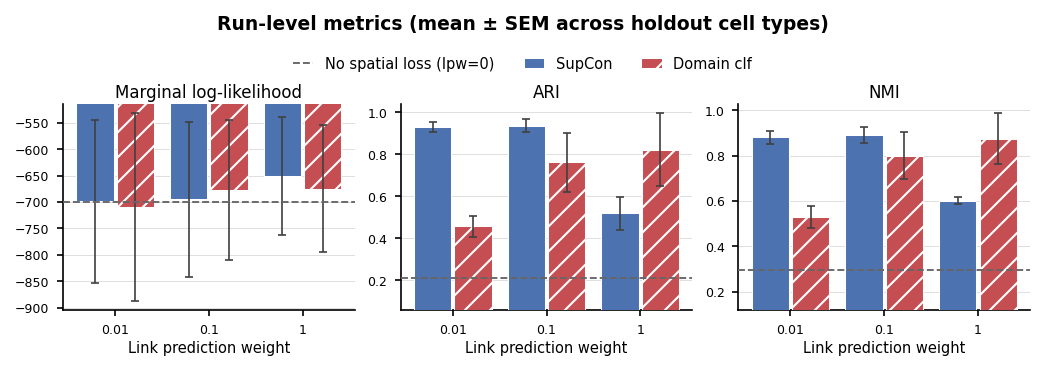

In [8]:
agg_run_dict = agg_run(df)

fig3, axes3 = plt.subplots(1, 3, figsize=(6.85, 1.9), constrained_layout=True)

for col_i, metric in enumerate(RUN_METRICS):
    ax  = axes3[col_i]
    vals = agg_run_dict[metric]
    lo  = (vals["mean"] - vals["sem"]).min()
    hi  = (vals["mean"] + vals["sem"]).max()
    rng = hi - lo
    ylim = (lo - 0.05 * rng, hi + 0.05 * rng)

    grouped_barplot(
        ax, agg_run_dict[metric],
        lpw_order=LPW_ORDER, tick_labels=LPW_TICK_LABELS,
        slt_order=SLT_ORDER,
        slt_colors=SLT_COLORS, slt_hatches=SLT_HATCHES, slt_labels=SLT_LABELS,
        baseline=baseline_val(agg_run_dict[metric]),
        title=METRIC_LABELS[metric],
        show_xlabel=True,
        ylim=ylim,
    )

handles, labels = axes3[0].get_legend_handles_labels()
fig3.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.12),
            ncols=len(handles), fontsize=7, frameon=False, handlelength=1.4)
fig3.suptitle("Run-level metrics (mean ± SEM across holdout cell types)",
              fontsize=9, weight="bold", y=1.22)
plt.show()

## Save all figures

In [9]:
import os
os.makedirs("results", exist_ok=True)

fig1.savefig("results/fig_cf_summary.pdf",   bbox_inches="tight", dpi=300)
fig2.savefig("results/fig_cf_by_target.pdf", bbox_inches="tight", dpi=300)
fig3.savefig("results/fig_run_metrics.pdf",  bbox_inches="tight", dpi=300)

print("Saved:")
print("  results/fig_cf_summary.pdf")
print("  results/fig_cf_by_target.pdf")
print("  results/fig_run_metrics.pdf")

Saved:
  results/fig_cf_summary.pdf
  results/fig_cf_by_target.pdf
  results/fig_run_metrics.pdf
